正在加载 OBO 文件，请稍候...
C:/Users/jingqing/Desktop/fsdownload/question3/enrichment/go-basic.obo: fmt(1.2) rel(2025-10-10) 51,842 Terms; optional_attrs(consider replaced_by)
OBO 加载完成。
正在映射 Ontology 分类...
正在生成多系统合并的 GO 状态审计日志...
数据清洗完毕：共保留了 910 条有效结果，合并表中共丢弃了 61 条废弃结果。
正在绘制 Cellular Component 比较矩阵...


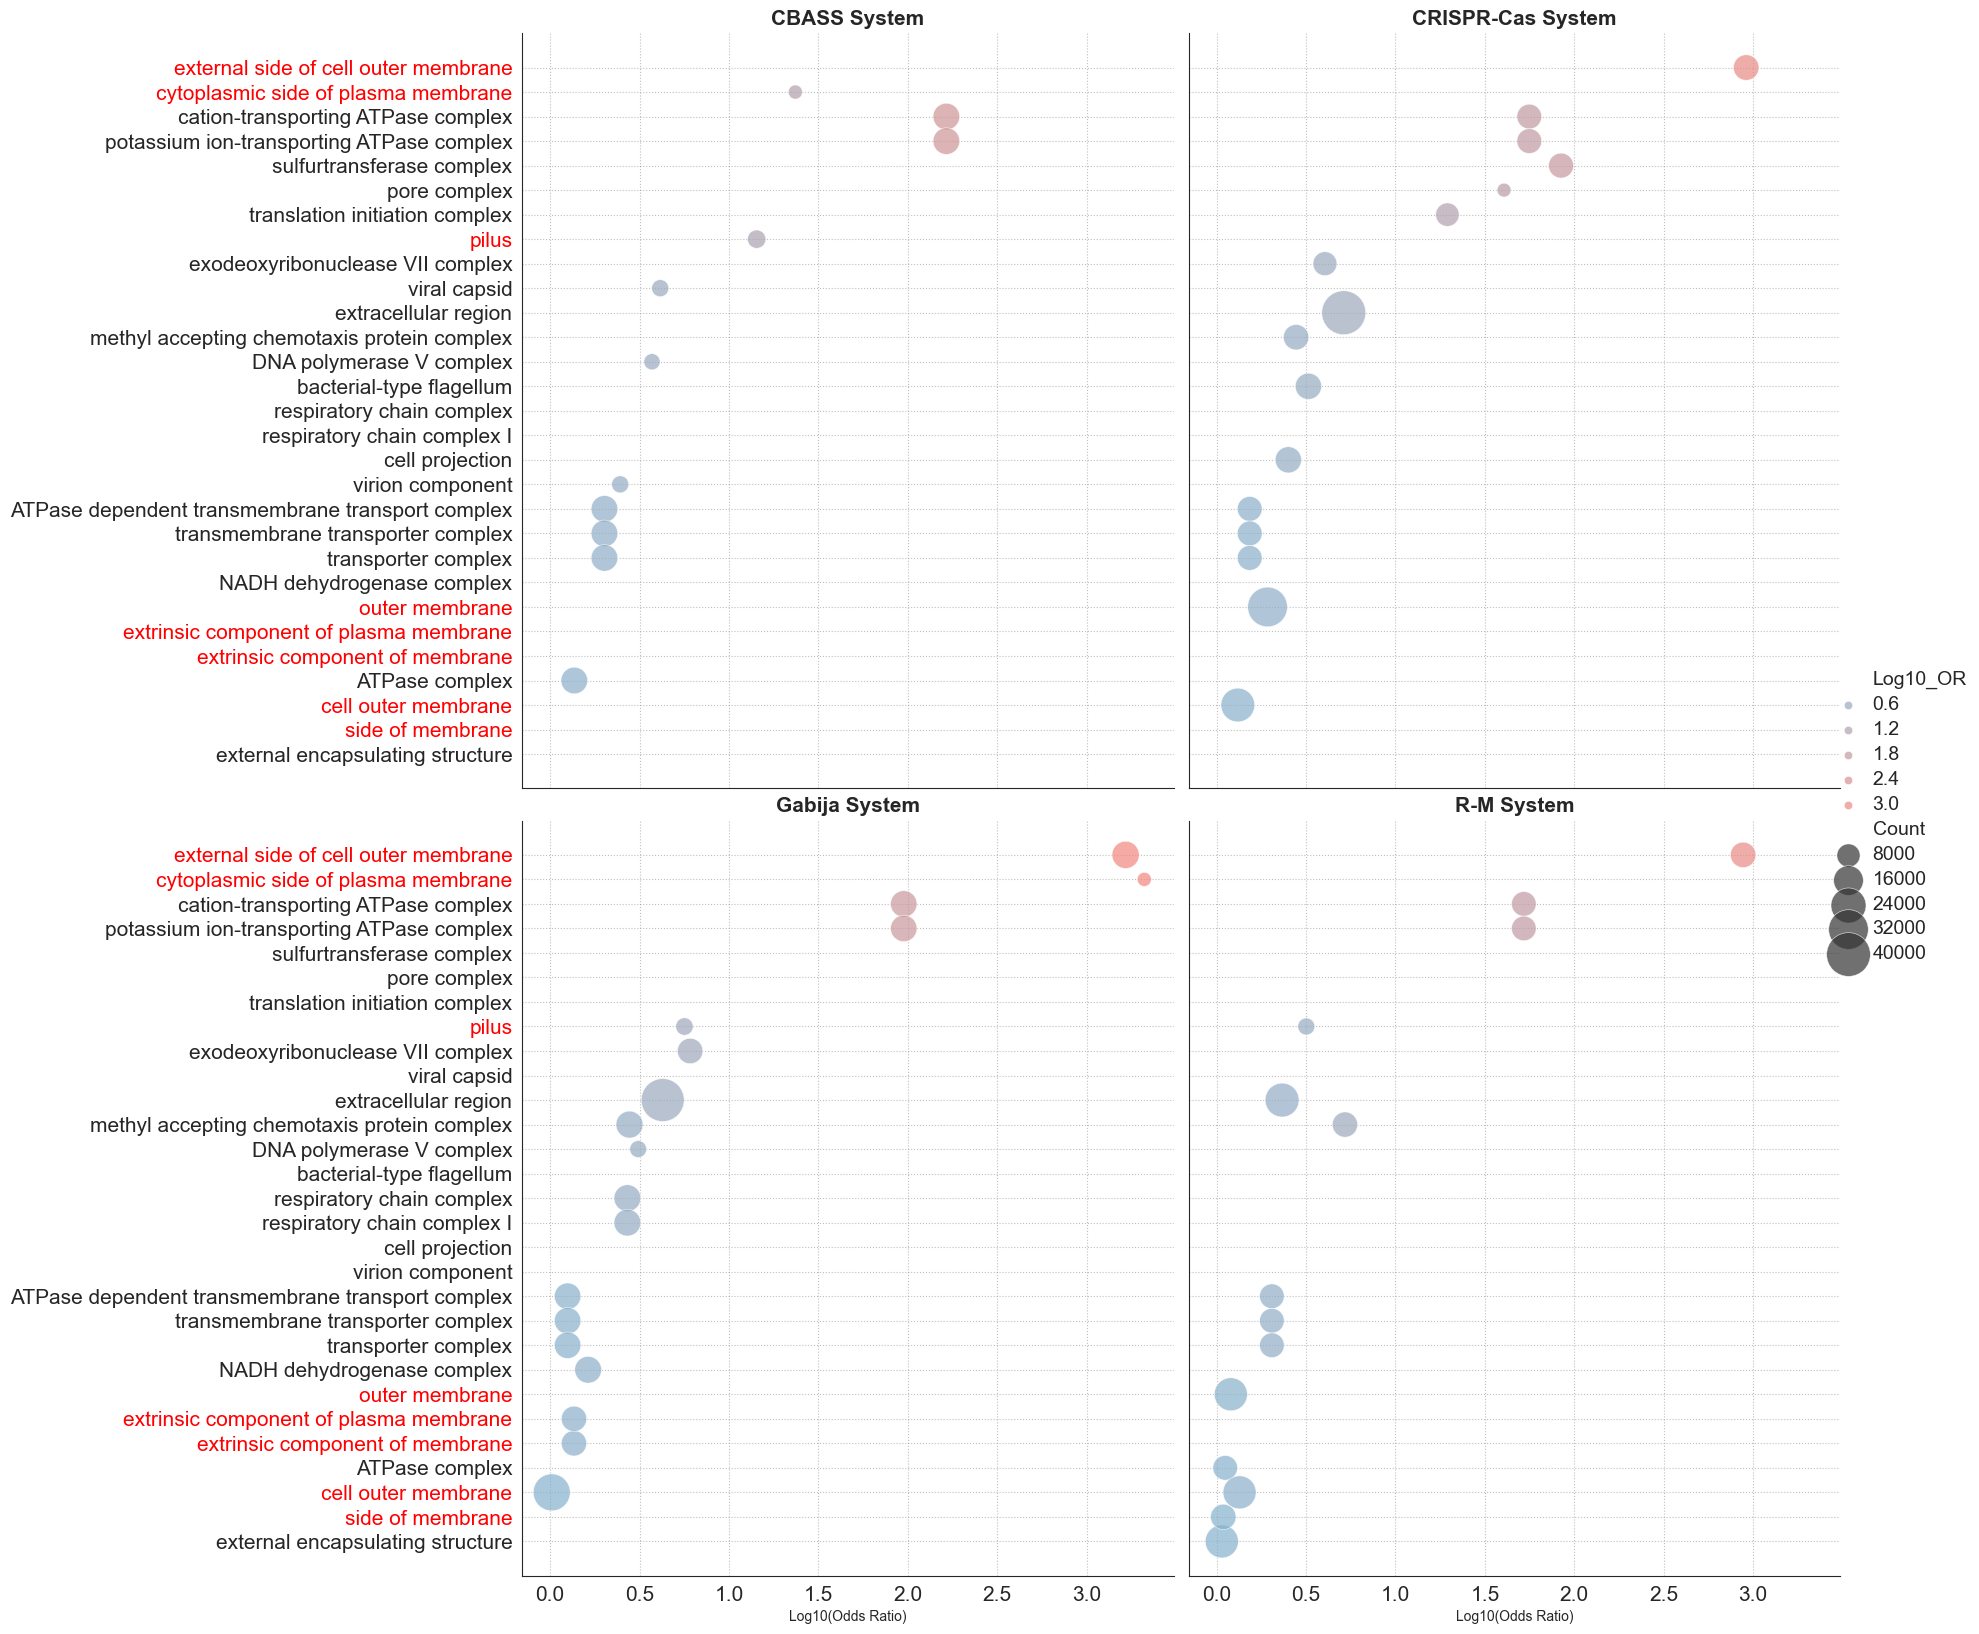

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from goatools.obo_parser import GODag
from matplotlib.colors import LinearSegmentedColormap

# --- 全局设置 Seaborn 样式为白底 ---
sns.set_style("white")

# --- 1. 配置与加载 ---
# 定义 4 个系统的文件路径字典 (请确保后三个文件的真实路径正确)
files = {
}

obo_path = ""
print("正在加载 OBO 文件，请稍候...")
godag = GODag(obo_path, optional_attrs=['replaced_by', 'consider'], load_obsolete=True)
print("OBO 加载完成。")

# 循环读取并合并所有数据
all_dfs = []
for system_name, path in files.items():
    try:
        temp_df = pd.read_csv(path, sep="\t")
        temp_df['System'] = system_name # 添加系统标识列，用于区分数据来源
        all_dfs.append(temp_df)
    except FileNotFoundError:
        print(f"警告：未找到 {system_name} 的文件 ({path})，已跳过。")

if not all_dfs:
    raise ValueError("错误：未能成功加载任何数据文件，请检查文件路径是否正确。")

# 合并为一个大的 DataFrame
df_combined = pd.concat(all_dfs, ignore_index=True)

# --- 2. 基础数据清洗与计算 ---
df_combined['Odds Ratio'] = pd.to_numeric(df_combined['Odds Ratio'], errors='coerce')
# 处理 Overlap 列，提取分子数
df_combined['Count'] = df_combined['Overlap'].apply(lambda x: int(str(x).split('/')[0]) if pd.notnull(x) else 0)
df_combined['Log10_OR'] = np.log10(df_combined['Odds Ratio'])

# --- 3. 获取 Ontology (BP, CC, MF) ---
def get_ontology(go_id):
    if go_id in godag:
        namespace = godag[go_id].namespace
        if namespace == 'biological_process':
            return 'BP'
        elif namespace == 'cellular_component':
            return 'CC'
        elif namespace == 'molecular_function':
            return 'MF'
    return 'BP'

print("正在映射 Ontology 分类...")
df_combined['Ontology'] = df_combined['Term'].apply(get_ontology)

# --- 4. GO 号审计与更新 ---
def audit_and_update_go(go_id):
    is_obsolete = False
    replaced_by_id = np.nan
    status = "Valid"
    final_id = go_id

    original_name = godag[go_id].name if go_id in godag else str(go_id)

    if go_id in godag:
        go_term = godag[go_id]
        if go_term.is_obsolete:
            is_obsolete = True
            if hasattr(go_term, 'replaced_by') and go_term.replaced_by:
                if isinstance(go_term.replaced_by, (list, set)) and len(go_term.replaced_by) > 0:
                    replaced_by_id = list(go_term.replaced_by)[0]
                elif isinstance(go_term.replaced_by, str):
                    replaced_by_id = go_term.replaced_by
                status = "Replaced"
                final_id = replaced_by_id
            elif hasattr(go_term, 'consider') and go_term.consider:
                status = "Obsolete (Dropped_Consider)"
                final_id = None
            else:
                status = "Obsolete (Dropped_No_Suggestion)"
                final_id = None
    else:
        status = "Not Found in OBO"

    return pd.Series([original_name, is_obsolete, replaced_by_id, status, final_id])

print("正在生成多系统合并的 GO 状态审计日志...")
df_combined[['Original_GO_Name', 'Is_Obsolete', 'Replaced_GO_ID', 'Status', 'Final_Term']] = df_combined['Term'].apply(audit_and_update_go)

# --- 执行丢弃与清洗逻辑 ---
df_combined['Term'] = df_combined['Final_Term']
original_len = len(df_combined)
df_combined = df_combined.dropna(subset=['Term']).reset_index(drop=True)
dropped_len = original_len - len(df_combined)
print(f"数据清洗完毕：共保留了 {len(df_combined)} 条有效结果，合并表中共丢弃了 {dropped_len} 条废弃结果。")

# --- 5. 提取 CC 类别并绘制矩阵图 ---
df_cc = df_combined[df_combined['Ontology'] == 'CC'].copy()

# 将有效的 GO ID 映射为具体的 GO_Name
def get_go_name(go_id):
    if go_id in godag:
        return godag[go_id].name
    return go_id
df_cc['GO_Name'] = df_cc['Term'].apply(get_go_name)

# ==================== 新增的修复逻辑开始 ====================
# 1. 优先按 Odds Ratio 降序排序，确保最显著的结果排在前面
df_cc = df_cc.sort_values(by=['System', 'GO_Name', 'Odds Ratio'], ascending=[True, True, False])

# 2. 针对【防御系统类型】和【GO_Name】的组合进行去重，保留第一项（即 OR 值最高的一项）
df_cc = df_cc.drop_duplicates(subset=['System', 'GO_Name'], keep='first')
# ==================== 新增的修复逻辑结束 ====================

# 统一排序逻辑：按所有系统中该功能的平均 Odds Ratio 降序排序
go_order = df_cc.groupby('GO_Name')['Odds Ratio'].mean().sort_values(ascending=False).index
df_cc['GO_Name'] = pd.Categorical(df_cc['GO_Name'], categories=go_order, ordered=True)

# --- 在提取 df_cc 后，开始绘图前 ---
# 定义科学名称的映射字典
system_name_map = {
    'gabija': 'Gabija',
    'rm': 'R-M',
    'cbass': 'CBASS',
    'crispr': 'CRISPR-Cas'
}
# 替换 System 列中的内容
df_cc['System'] = df_cc['System'].replace(system_name_map)


# ... 后面接着原有的绘图代码 (sns.relplot ...)

# 提取你原先定义的色板
# 定义新的极值颜色色板
color_1 = "#F4867C" # 浅蓝色 (低值)
color_2 = "#86B1CD" # 珊瑚红 (高值)

# 生成在这两个颜色之间渐变的色板
custom_cmap = LinearSegmentedColormap.from_list("custom_palette", [color_2, color_1])

# 开始绘制矩阵气泡图 (FacetGrid)
print("正在绘制 Cellular Component 比较矩阵...")
g = sns.relplot(
    data=df_cc,
    x="Log10_OR",
    y="GO_Name",
    hue="Log10_OR",
    size="Count",
    col="System",      # 决定分面的列
    col_wrap=2,        # 一行展示2个子图，共2行 (2x2)
    palette=custom_cmap,
    sizes=(100, 1000), # 气泡大小范围
    edgecolor="w",
    alpha=0.7,
    linewidth=0.5,
    height=max(6, len(go_order) * 0.3), # 动态高度，防止 y 轴拥挤
    aspect=1.0         # 宽高比设定为 1:1，可根据需要微调
)

# 细节调整与美化
g.set_titles("{col_name} System", size=15, fontweight='bold')
g.set_axis_labels("Log10(Odds Ratio)", "") # Y轴留白，避免冗余

for ax in g.axes.flat:
    # 增加网格辅助线，并在下方显示
    ax.grid(True, linestyle=':', alpha=0.5, color='gray')
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=15)
    # # ====== 2. 新增：动态高亮特定关键词的逻辑 ======
    # 获取当前子图的所有 Y 轴文字标签对象
    for label in ax.get_yticklabels():
        text_content = label.get_text()

        # 将文本转换为小写进行匹配，防止大小写导致遗漏
        if ('membrane' in text_content.lower() or 'pilus' in text_content.lower()) and 'transmembrane' not in text_content.lower():
            # 修改字体颜色为红色
            label.set_color('red')
            # # 建议同时加粗，以增强视觉对比度 (可选)
            # label.set_fontweight('bold')

# 控制图例标题的大小
plt.setp(g._legend.get_title(), fontsize=14, fontweight='bold')
# 控制图例内部文字（数值和系统类别）的大小
plt.setp(g._legend.get_texts(), fontsize=14)

# 全局主标题留足空间
plt.subplots_adjust(top=0.92)
# g.fig.suptitle("Comparative Cellular Component Enrichment across Defense Systems", fontsize=16)

# 保存最终图像

# print(f"对比图已生成，保存至: {save_path}")

plt.show()